Testing the new scalar vortex coronagraph optic in poppy_utils, SVC_branch.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'image.origin' : 'lower',
})
from matplotlib.colors import LogNorm

import poppy_utils as pu
from copy import deepcopy
import numpy as np
import os
import cupy as cp
import cupy.cuda

/home/wcmelby/projects/venv-scoob-poppy/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Make a plot of how the phase wraps for a wavelength that is different from the design wavelength

Text(0.5, 1.0, '2')

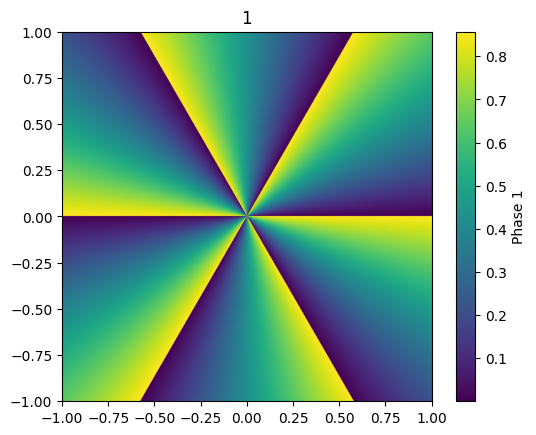

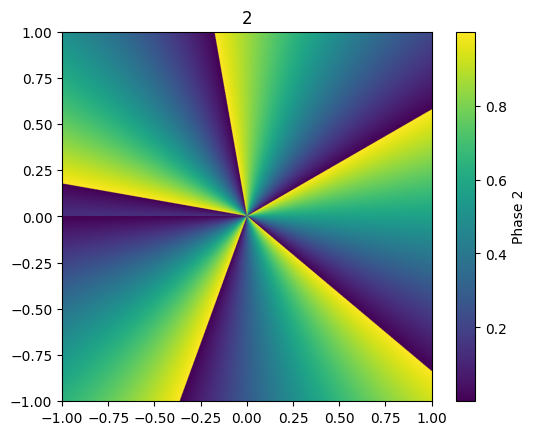

In [29]:
charge = 6
design_wl = 600
testing_wl = 700
x, y = np.meshgrid(np.linspace(-1, 1, 1000), np.linspace(-1, 1, 1000))
azimuthal_phase = charge * np.arctan2(y, x)
relative_phase1 = np.mod(azimuthal_phase, 2*np.pi)
relative_phase2 = (np.arctan2(y, x) + np.pi) * charge

# The OPD imparted by the glass will be fixed and determined by the design wavelength
opd1 = relative_phase1 * design_wl / (2*np.pi)
opd2 = relative_phase2 * design_wl / (2*np.pi)

# The phase of the light off-band will be different
phase1 = opd1 / testing_wl
phase2 = opd2 / testing_wl
phase1 = np.mod(phase1, 1)
phase2 = np.mod(phase2, 1)

plt.figure()  # Create a new figure
plt.imshow(phase1, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='Phase 1')
plt.title('1')

plt.figure()  # Create a new figure
plt.imshow(phase2, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='Phase 2')
plt.title('2')

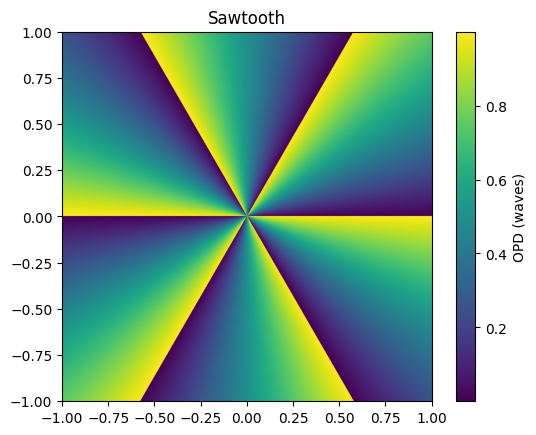

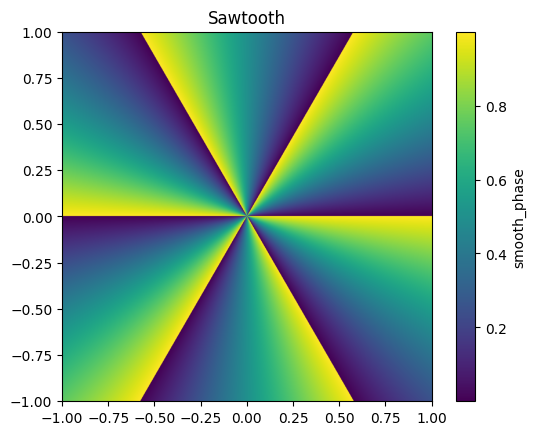

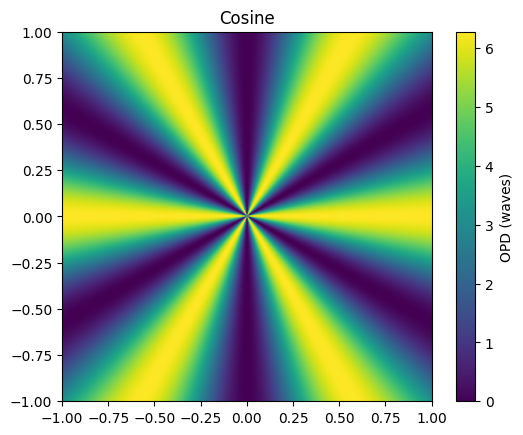

In [19]:
# make a 2d plot of opd
charge = 6
wavelength = 1
x, y = np.meshgrid(np.linspace(-1, 1, 1000), np.linspace(-1, 1, 1000))
azimuthal_phase = charge*np.arctan2(y, x)
relative_phase = np.mod(azimuthal_phase, 2*np.pi) # sawtooth
smooth_phase = (np.arctan2(y, x)+np.pi) * charge
smooth_phase = np.mod(smooth_phase, 2*np.pi)

phasor = np.exp(1j*azimuthal_phase)
real_part = (np.real(phasor)+1)*np.pi

dimple_size = 0.2
dimple_size=None
f_number = 1
if dimple_size is not None:
    r = np.sqrt(x**2 + y**2)
    dimple_radius_m = dimple_size * wavelength * f_number
    # Need to convert x,y coordinates to arcseconds to get the right dimple size in lambda/D
    relative_phase[r < dimple_radius_m] += np.pi

opd = relative_phase*wavelength/(2*np.pi)

plt.figure()  # Create a new figure
plt.imshow(opd, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='OPD (waves)')
plt.title('Sawtooth')

plt.figure()  # Create a new figure
plt.imshow(smooth_phase/(2*np.pi), extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='smooth_phase')
plt.title('Sawtooth')

plt.figure()  # Create another figure
plt.imshow(real_part, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='OPD (waves)')
plt.title('Cosine')

plt.show()

In [3]:
# Check the detected CUDA version
print(f"CuPy Version: {cp.__version__}")
print(f"CUDA Version: {cupy.cuda.runtime.runtimeGetVersion()}")

# Perform a simple GPU operation
x = cp.array([1, 2, 3])
print(f"Array on GPU: {x}")
print(f"Device: {x.device}")

CuPy Version: 13.6.0
CUDA Version: 12090
Array on GPU: [1 2 3]
Device: <CUDA Device 0>


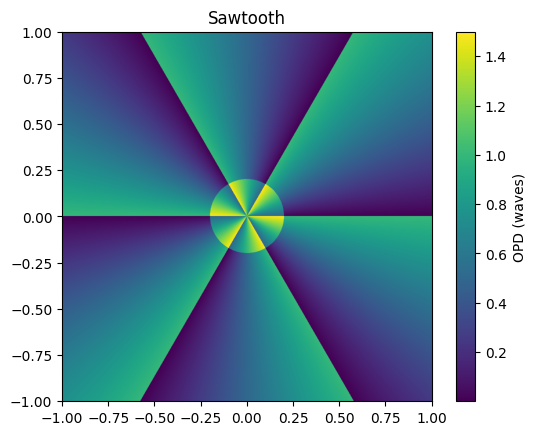

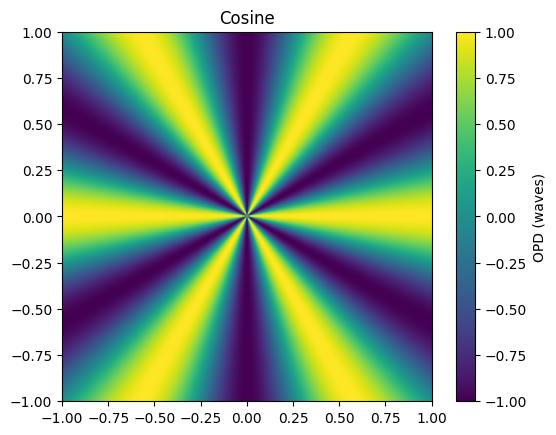

In [2]:
# make a 2d plot of opd
charge = 6
wavelength = 1
x, y = np.meshgrid(np.linspace(-1, 1, 1000), np.linspace(-1, 1, 1000))
azimuthal_phase = charge*np.arctan2(y, x)
relative_phase = np.mod(azimuthal_phase, 2*np.pi)

phasor = np.exp(1j*azimuthal_phase)
real_part = np.real(phasor)

dimple_size = 0.2
f_number = 1
if dimple_size is not None:
    r = np.sqrt(x**2 + y**2)
    dimple_radius_m = dimple_size * wavelength * f_number
    # Need to convert x,y coordinates to arcseconds to get the right dimple size in lambda/D
    relative_phase[r < dimple_radius_m] += np.pi

opd = relative_phase*wavelength/(2*np.pi)


plt.figure()  # Create a new figure
plt.imshow(opd, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='OPD (waves)')
plt.title('Sawtooth')

plt.figure()  # Create another figure
plt.imshow(real_part, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='OPD (waves)')
plt.title('Cosine')

plt.show()

In [2]:
osys, wf, osys_dict, metadata = pu.load_optical_system('svc_example_fresnel.toml')
osys.describe()

	Entrance pupil diam:  0.06 m	npix: 1024	Beam ratio:0.25
	Optic: EP
	Propagation distance:  0.994375 m
	Optic: OAP1
	Optic: SVC
	Propagation distance:  0.24635742217700002 m
	Detector plane: Science detector (500x500 pixels, 3.760 micron / pix)


In [3]:
om = pu.load_optical_system_into_model('svc_example_fresnel.toml')
print(om)
om.inspect_roc(do_print=True)

Plane 0, after EP: inf m, 0.000000 m
Plane 1, after OAP1: 35632587.489565 m, 0.994375 m
Plane 2, after SVC: 35632587.489565 m, 0.994375 m
Plane 3, at Science detector: 28557450.504438 m, 1.240732 m


[<Quantity inf m>,
 <Quantity 35632587.48956503 m>,
 <Quantity 35632587.48956503 m>,
 <Quantity 28557450.50443831 m>]

In [4]:
# wfout, wflist = om.run_mono(return_intermediates=True, tiptilt=(1,0))
wfout, wflist = om.run_mono(return_intermediates=True)

norm = wfout.intensity.max()
# print(norm)

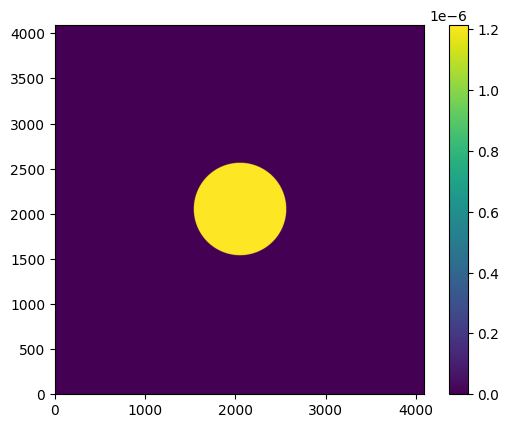

In [5]:
# instrument pupil
idx=0
plt.imshow(wflist[idx].intensity.get())
plt.colorbar()

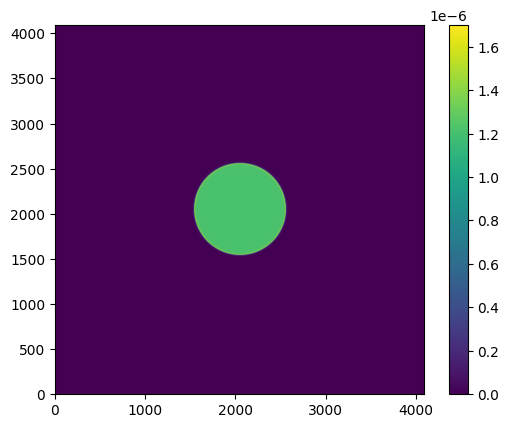

In [6]:
# OAP1
idx=1
plt.imshow(wflist[idx].intensity.get())
plt.colorbar()

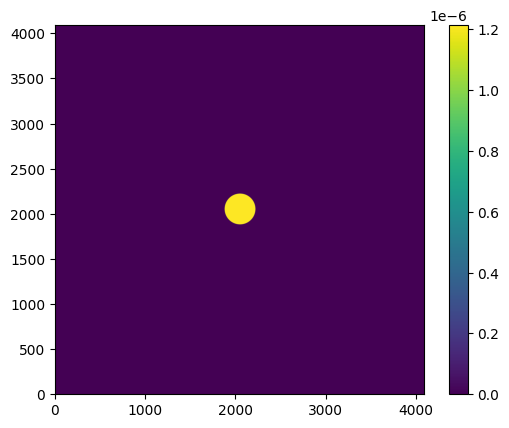

In [5]:
# SVC
idx=2
plt.imshow(wflist[idx].intensity.get())
plt.colorbar()